In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/MyDrive/dataset_12000_records.csv")

In [ ]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,...,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days
0,PT_00001,65,Female,25.564766,No,No,0,1,0,0,...,95.586026,118.407920,13,0,1,1,1,0,0,0
1,PT_00002,83,Male,30.503110,Yes,Yes,1,1,1,1,...,142.445450,421.440746,4,1,1,1,1,1,1,1
2,PT_00003,76,Male,21.934792,No,No,0,1,1,1,...,158.669171,240.351673,5,0,0,1,1,0,1,0
3,PT_00004,72,Female,22.048039,No,Yes,0,0,1,0,...,145.531173,334.414121,13,0,1,1,1,1,0,1
4,PT_00005,54,Male,27.102739,No,No,3,0,0,0,...,94.644198,71.006274,5,1,1,0,1,0,0,0


In [ ]:
row, col = df.shape
print(f"Row: {row} X Column: {col}")

Row: 12000 X Column: 36


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12000 non-null  object 
 1   Age                           12000 non-null  int64  
 2   Gender                        12000 non-null  object 
 3   BMI                           12000 non-null  float64
 4   Smoking_Status                12000 non-null  object 
 5   Alcohol_Consumption           12000 non-null  object 
 6   Exercise_Frequency            12000 non-null  int64  
 7   Hypertension                  12000 non-null  int64  
 8   Diabetes                      12000 non-null  int64  
 9   Chronic_Kidney_Disease        12000 non-null  int64  
 10  Coronary_Artery_Disease       12000 non-null  int64  
 11  Previous_Stroke               12000 non-null  int64  
 12  Atrial_Fibrillation           12000 non-null  int64  
 13  P

In [ ]:
df.describe()

,Age,BMI,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,Coronary_Artery_Disease,Previous_Stroke,Atrial_Fibrillation,Previous_HF_Admissions,...,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,67.396417,27.790903,1.018583,0.412417,0.296667,0.268000,0.401500,0.183083,0.277333,0.631083,...,118.077890,204.936134,8.146667,0.339917,0.511667,0.804167,0.762000,0.576667,0.395000,0.300000
std,13.079380,5.035375,1.036819,0.492290,0.456807,0.442936,0.490222,0.386751,0.447701,0.874765,...,32.696853,203.739039,6.472865,0.473700,0.499885,0.396857,0.425877,0.494108,0.488871,0.458277
min,30.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,70.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,24.299963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.609403,84.818008,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,68.000000,27.780840,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,115.999968,142.847005,6.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,77.000000,31.246772,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,139.825765,248.264021,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,95.000000,45.975566,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,...,258.524090,4097.436155,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,Coronary_Artery_Disease,Previous_Stroke,Atrial_Fibrillation,Previous_HF_Admissions,Previous_Hospital_Admissions,Heart_Failure_Type,NYHA_Class,Ejection_Fraction,Systolic_BP,Diastolic_BP,Heart_Rate,Oxygen_Saturation,Creatinine,Sodium,Potassium,Hemoglobin,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days,
PT_11984,58,Female,29.050269,No,No,2,1,0,0,0,1,0,0,1,HFrEF,2,37.120275,131.931047,101.374414,82.790346,94.993370,0.500000,144.457731,3.253580,15.143870,70.000000,65.430876,13,0,1,1,0,0,0,0,1
PT_11983,60,Male,40.563513,Yes,No,0,1,1,0,1,0,0,0,1,HFmrEF,2,49.072153,126.654053,98.867865,71.038537,91.127495,0.500000,142.254589,4.166732,11.522548,150.027753,85.222816,5,0,0,1,1,1,0,0,1
PT_11982,36,Male,34.300925,No,No,3,0,0,0,0,1,0,0,1,HFrEF,1,34.424034,127.976680,76.679560,83.361301,95.001361,0.500000,141.066402,3.409260,12.780670,142.916381,137.732432,2,0,1,1,1,1,0,0,1
PT_11981,58,Female,37.822932,No,No,0,1,0,0,0,0,1,0,0,HFmrEF,4,43.698731,106.937675,61.147819,93.807356,94.866578,1.669398,144.244758,4.570356,13.277771,109.695672,92.717682,3,0,1,1,1,1,0,0,1
PT_11980,66,Male,34.460973,Yes,Yes,0,0,1,1,0,0,1,1,4,HFrEF,4,31.820510,100.834890,89.967018,91.870073,94.715683,1.428668,136.646802,3.996103,12.073362,174.600817,239.526651,16,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT_00005,54,Male,27.102739,No,No,3,0,0,0,0,0,0,0,0,HFrEF,1,32.191429,148.003110,88.125448,76.678998,94.432974,0.500000,135.468233,4.967968,11.944142,94.644198,71.006274,5,1,1,0,1,0,0,0,1
PT_00004,72,Female,22.048039,No,Yes,0,0,1,0,0,0,1,1,1,HFrEF,2,21.076920,130.631739,61.824051,95.985584,97.272233,0.583664,141.419697,4.402095,10.419273,145.531173,334.414121,13,0,1,1,1,1,0,1,1
PT_00003,76,Male,21.934792,No,No,0,1,1,1,0,1,0,0,1,HFrEF,2,37.041207,115.263282,72.673929,73.456178,90.744054,7.117233,135.292245,4.536233,10.816606,158.669171,240.351673,5,0,0,1,1,0,1,0,1


In [ ]:
df.notnull().count()

,0
Patient_ID,12000
Age,12000
Gender,12000
BMI,12000
Smoking_Status,12000
Alcohol_Consumption,12000
Exercise_Frequency,12000
Hypertension,12000
Diabetes,12000
Chronic_Kidney_Disease,12000


In [ ]:
df.dtypes

,0
Patient_ID,object
Age,int64
Gender,object
BMI,float64
Smoking_Status,object
Alcohol_Consumption,object
Exercise_Frequency,int64
Hypertension,int64
Diabetes,int64
Chronic_Kidney_Disease,int64


In [ ]:
dup_count = df.duplicated().sum()
print(dup_count)

0


In [4]:
X = df.drop(['Patient_ID','Readmitted_30_Days', 'Gender'], axis=1)
y= df['Readmitted_30_Days']

In [5]:
print("Target:", y.name)
print("Target in X:", y.name in X.columns)

Target: Readmitted_30_Days
Target in X: False


In [6]:
print(X.columns.tolist())

['Age', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke', 'Atrial_Fibrillation', 'Previous_HF_Admissions', 'Previous_Hospital_Admissions', 'Heart_Failure_Type', 'NYHA_Class', 'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission', 'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic', 'SGLT2_Inhibitor']


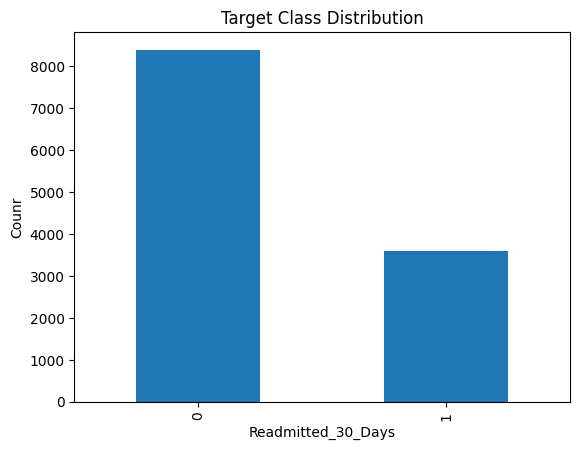

In [ ]:
y.value_counts().plot(kind='bar')
plt.xlabel('Readmitted_30_Days')
plt.ylabel('Counr')
plt.title("Target Class Distribution")
plt.show()

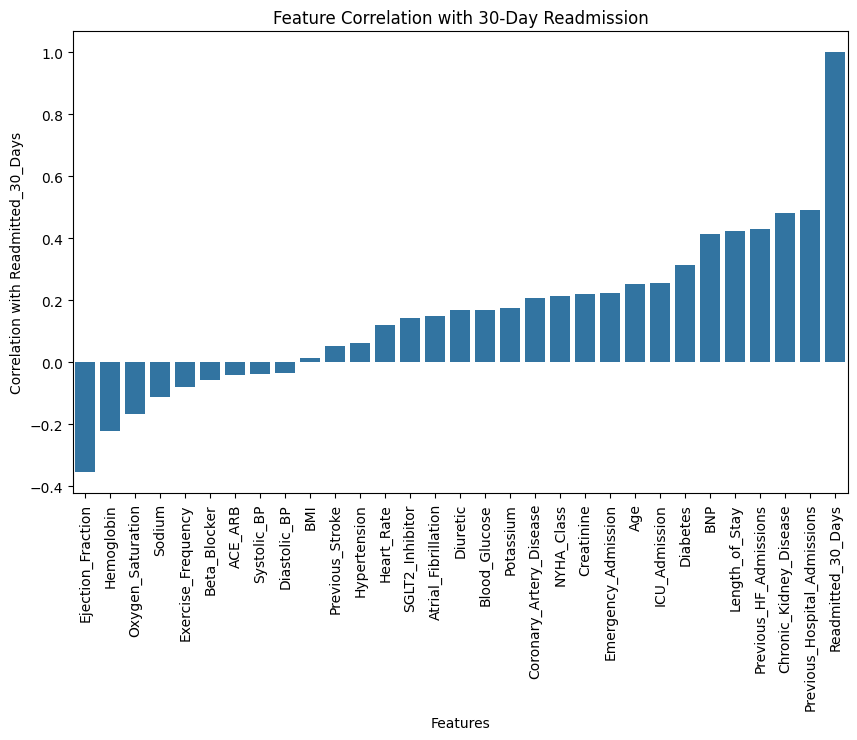

In [13]:
corr = df.corr(numeric_only=True)['Readmitted_30_Days'].sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=corr.index, y=corr.values)

plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Correlation with Readmitted_30_Days')
plt.title('Feature Correlation with 30-Day Readmission')

plt.show()

In [ ]:
cat_features = ['Smoking_Status',
    'Alcohol_Consumption',
    'Heart_Failure_Type']

num_features = ['Age',
    'BMI',
    'Ejection_Fraction',
    'Systolic_BP',
    'Diastolic_BP',
    'Heart_Rate',
    'Oxygen_Saturation',
    'Creatinine',
    'Sodium',
    'Potassium',
    'Hemoglobin',
    'Blood_Glucose',
    'BNP']

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ('num_features', StandardScaler(), num_features),
        ('cat_features', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
log_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(max_iter=1000))
])
tree_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', DecisionTreeClassifier())
])
knn_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', KNeighborsClassifier())
])

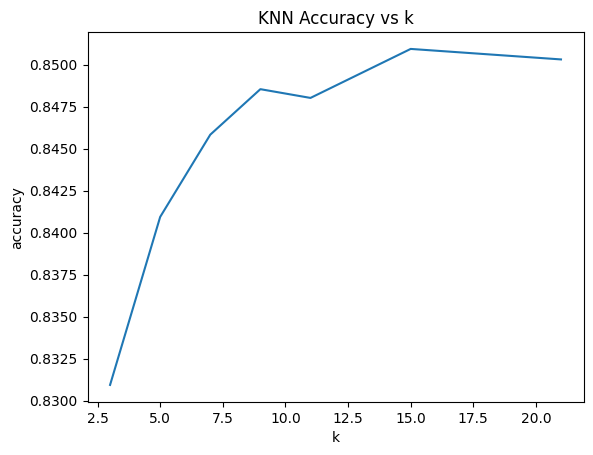

In [ ]:
k = [3, 5, 7, 9, 11, 15, 21]
knn_result = []
for i in k:
  knn_pipeline = knn_model.set_params(classifier__n_neighbors=i)
  scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  knn_result.append({'k': i, 'accuracy': scores.mean()})
knn_result_df = pd.DataFrame(knn_result)
plt.plot(knn_result_df['k'], knn_result_df['accuracy'])
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('KNN Accuracy vs k')
plt.show()

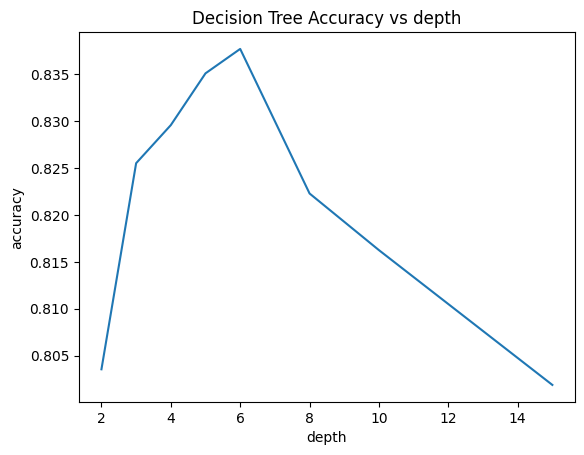

In [ ]:
depth = [2, 3, 4, 5, 6, 8, 10, 15]
tree_result = []
for i in depth:
  tree_pipeline = tree_model.set_params(classifier__max_depth=i)
  scores = cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  tree_result.append({'depth': i, 'accuracy': scores.mean()})
tree_result_df = pd.DataFrame(tree_result)
plt.plot(tree_result_df['depth'], tree_result_df['accuracy'])
plt.xlabel('depth')
plt.ylabel('accuracy')
plt.title('Decision Tree Accuracy vs depth')
plt.show()

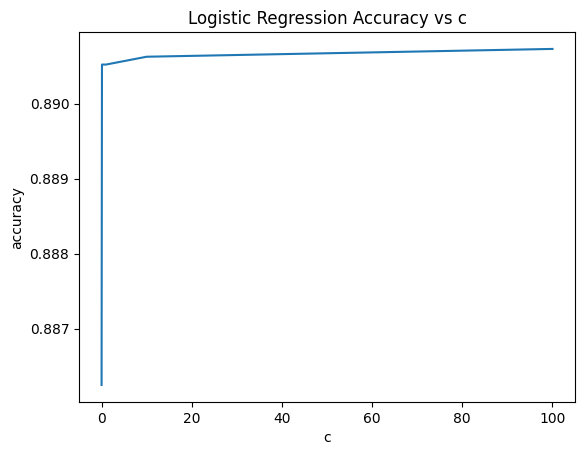

In [ ]:
c = [0.01, 0.1, 1, 10, 100]
log_result = []
for i in c:
  log_pipeline = log_model.set_params(classifier__C=i)
  scores = cross_val_score(log_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  log_result.append({'c': i, 'accuracy': scores.mean()})
log_result_df = pd.DataFrame(log_result)
plt.plot(log_result_df['c'], log_result_df['accuracy'])
plt.xlabel('c')
plt.ylabel('accuracy')
plt.title('Logistic Regression Accuracy vs c')
plt.show()

In [ ]:
models = {
    "Logistic Regression": log_model.set_params(classifier__C=1, classifier__max_iter=1000),
    "Decision Tree": tree_model.set_params(classifier__max_depth=6),
    "K-Nearest Neighbors": knn_model.set_params(classifier__n_neighbors=15)
}

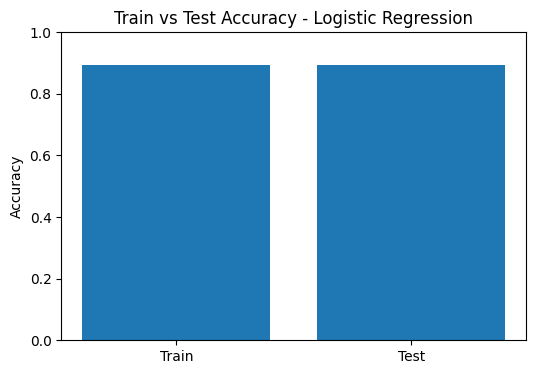

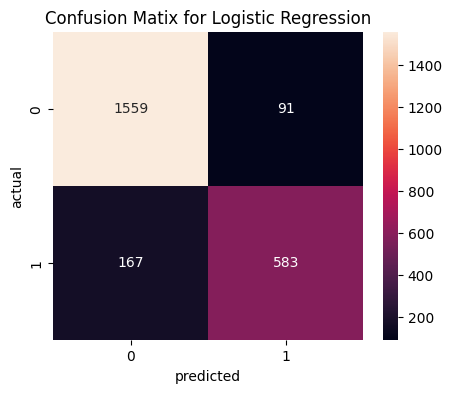

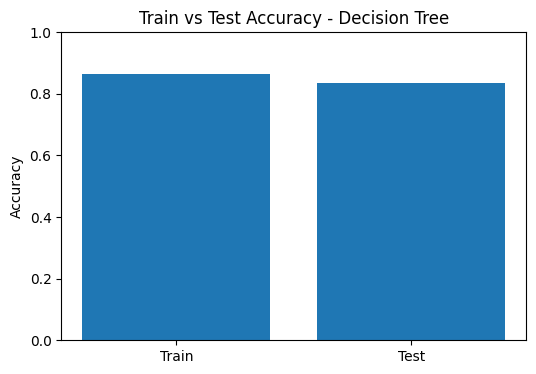

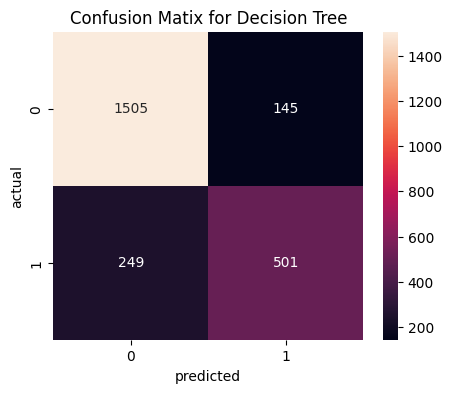

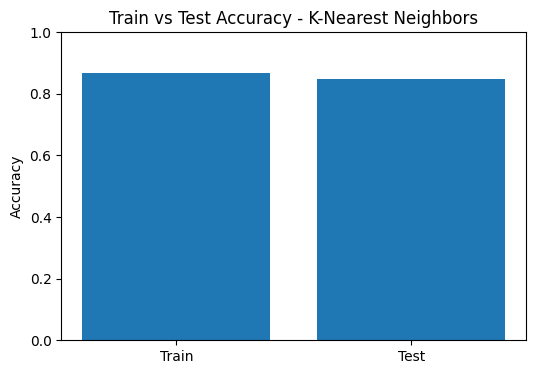

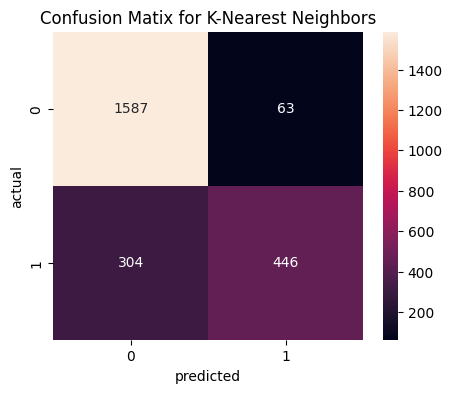

In [ ]:
result = []
for name, algo in models.items():
  algo.fit(X_train, y_train)
  y_pred = algo.predict(X_test)
  y_prob = algo.predict_proba(X_test)[:, 1]
  y_train_pred = algo.predict(X_train)
  y_test_pred = algo.predict(X_test)
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  result.append({
    "Model": name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc_score": roc_auc_score(y_test, y_prob),
    "train accuracy" : accuracy_score(y_train, y_train_pred),
    "test accuracy": accuracy_score(y_test, y_test_pred)})
  plt.figure(figsize=(6, 4))
  plt.bar(
    ['Train', 'Test'],
    [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)]
    )
  plt.ylim(0, 1)
  plt.ylabel('Accuracy')
  plt.title(f'Train vs Test Accuracy - {name}')
  plt.show()
  print("\n")
  plt.figure(figsize=(5, 4))
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f"Confusion Matix for {name}")
  plt.xlabel("predicted")
  plt.ylabel("actual")
  plt.show()
  print("\n")

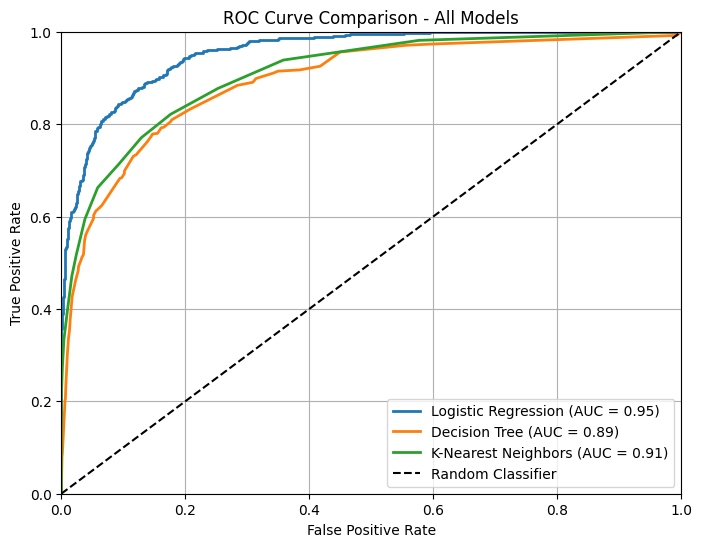

In [ ]:
plt.figure(figsize=(8, 6))
for name, algo in models.items():
    algo.fit(X_train, y_train)
    y_prob = algo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc:.2f})'
    )
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend()
plt.grid()
plt.show()

In [ ]:
comparison_table = pd.DataFrame(result)
print("Comparison Table: \n")
print(comparison_table)

Comparison Table: 

                 Model  Accuracy  precision    recall  f1_score  \
0  Logistic Regression  0.892500   0.864985  0.777333  0.818820   
1        Decision Tree  0.836667   0.776235  0.670667  0.719599   
2  K-Nearest Neighbors  0.847083   0.876228  0.594667  0.708499   

   roc_auc_score  train accuracy  test accuracy  
0       0.954620        0.893750       0.892500  
1       0.893778        0.863750       0.836667  
2       0.908293        0.867292       0.847083  


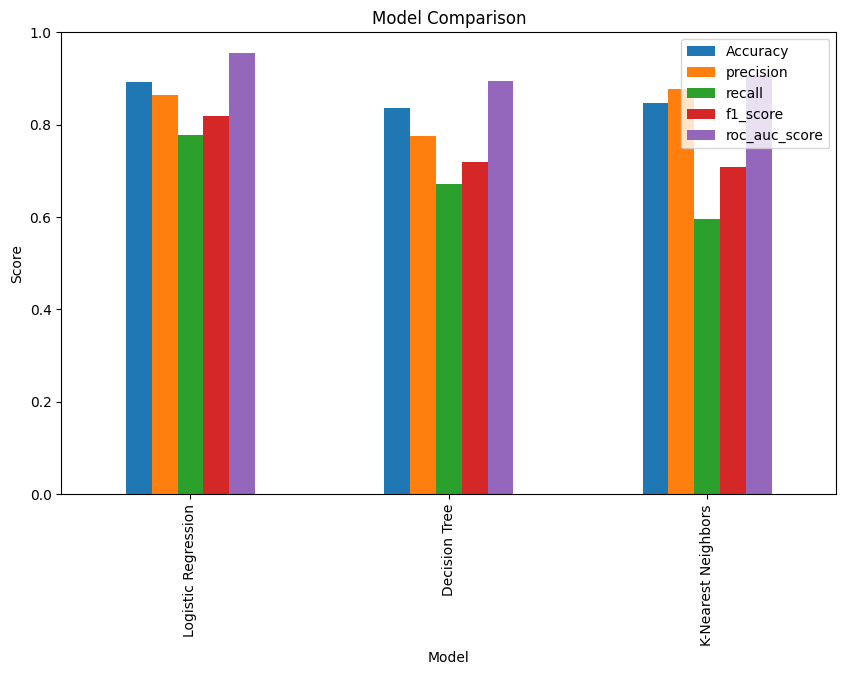

In [ ]:
metrics = ['Accuracy', 'precision', 'recall', 'f1_score', 'roc_auc_score']
comparison_table.plot(
    x='Model',
    y=metrics,
    kind='bar',
    figsize=(10,6)
)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.show()